# Find Optimal Bootsize

In this Example we will define the optimal bootsize as the bootsize that minimizes errors between the true (no-bootstrap) Structure function (longitudinal,transverse,advective,velocity,scalar) and the bootstrapped Structure Function


# Load Modules

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple
import warnings
import pyproj
import numpy as np
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.pyplot import cm
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Find Optimal Bootsize for different Functions (advective,scalar,longitudinal,transverse,velocity)

BOOTSIZE SENSITIVITY ANALYSIS

Base bootsize: 240 × 319
Testing bootsizes (x, y):
  60 × 79
  30 × 39
  15 × 19
  7 × 9
  3 × 4

Number of configurations to test: 7
  1. Longitudinal velocity SF2 (longitudinal, order=2)
  2. Transverse velocity SF2 (transverse, order=2)
  3. Default velocity SF2 (default_vel, order=2)
  4. Scalar SF1 (scalar, order=1)
  5. Advective (E gradients) (advective, order=1)
  6. Advective (pressure) (advective, order=1)
  7. Advective (stress) (advective, order=1)

CONFIG: Longitudinal velocity SF2 (longitudinal, order=2)

  Computing TRUE SF with bootsize x=240, y=319...
Dimensions ('y', 'x') are already in the expected order
Dimension y has bootsize equal to or larger than dimension size. No bootstrapping will be done across this dimension.
Dimension x has bootsize equal to or larger than dimension size. No bootstrapping will be done across this dimension.
Using bootsize: {'y': 319, 'x': 240}
Bootstrappable dimensions: []
No bootstrappable dimensions availa

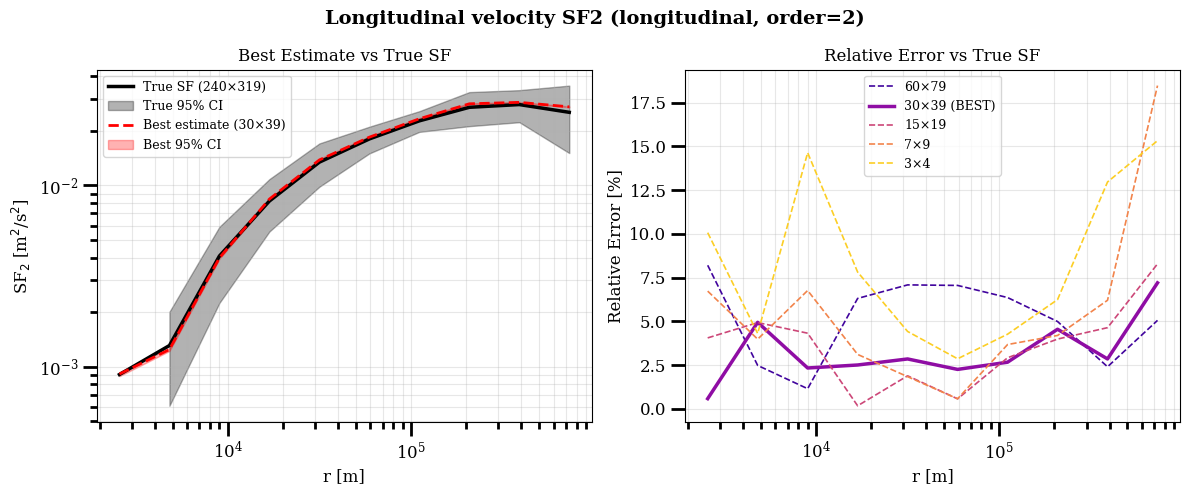

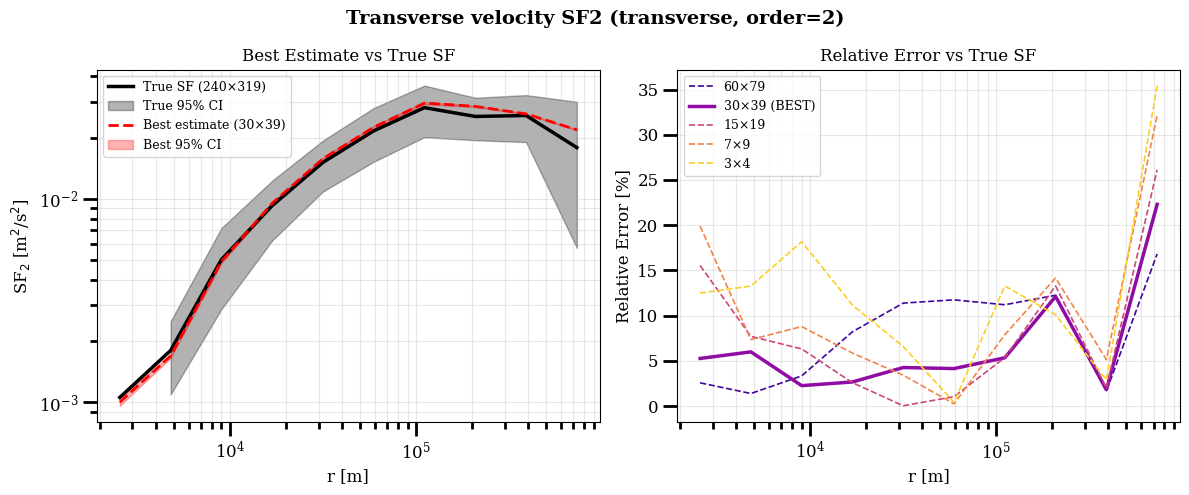

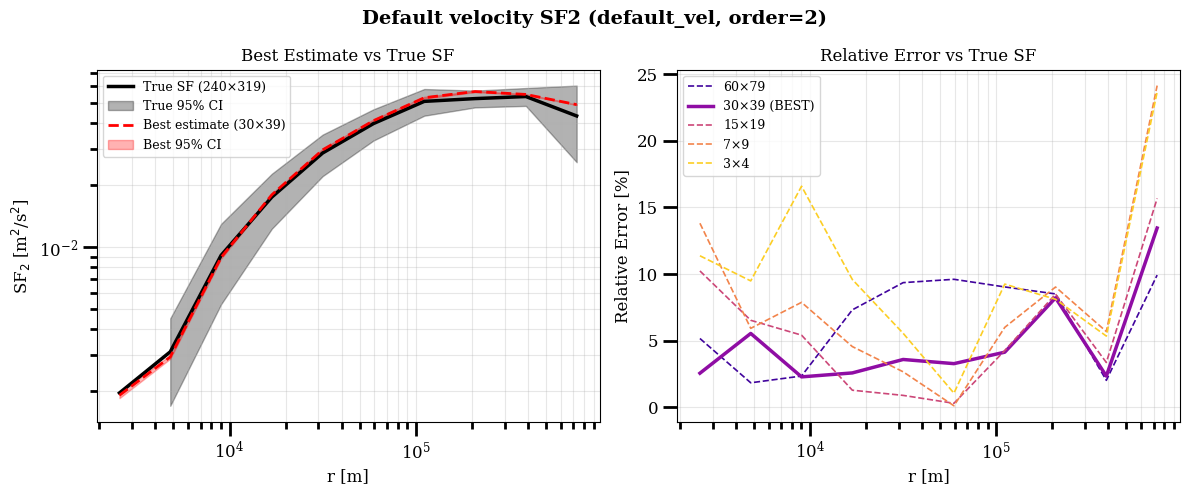

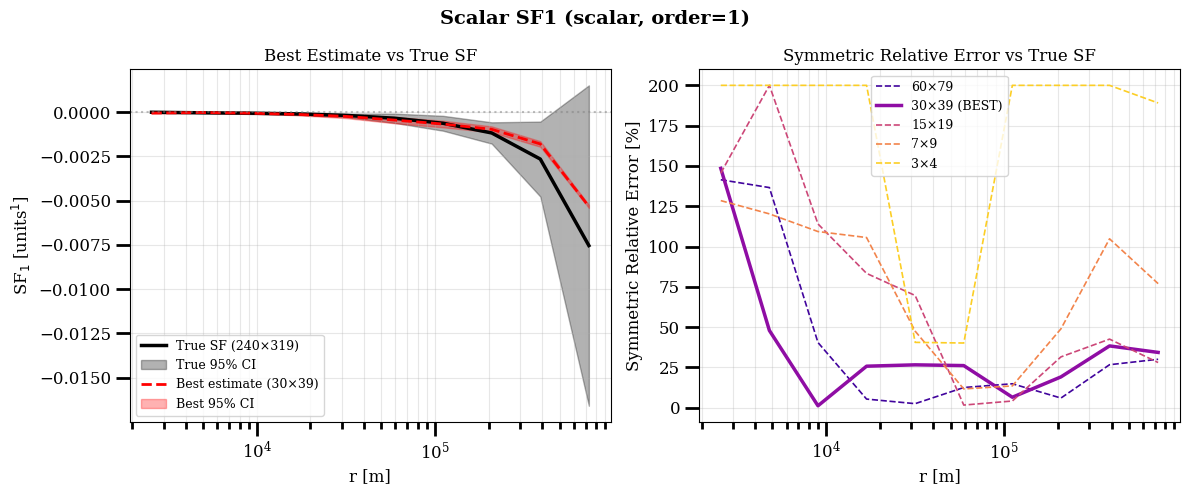

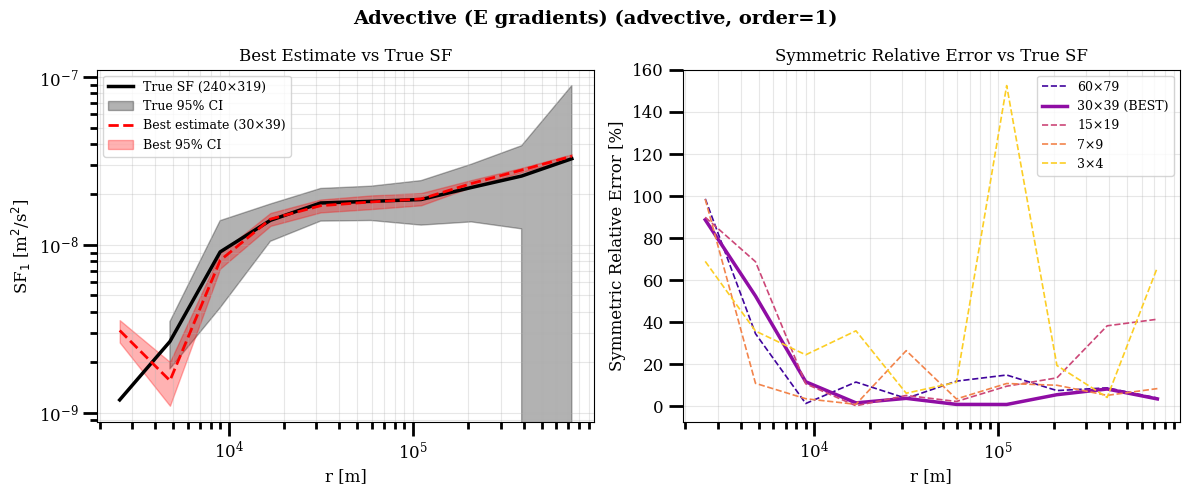

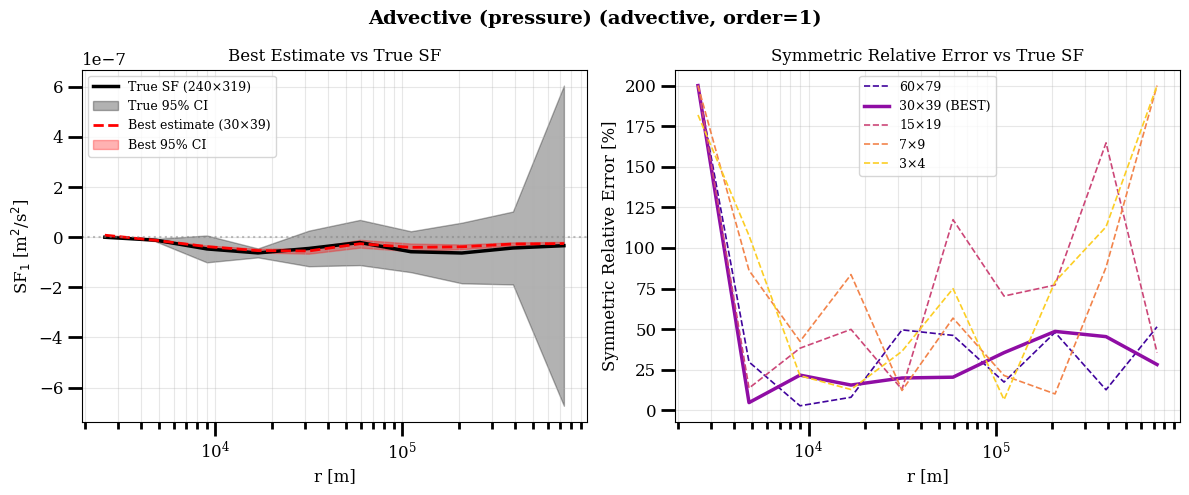

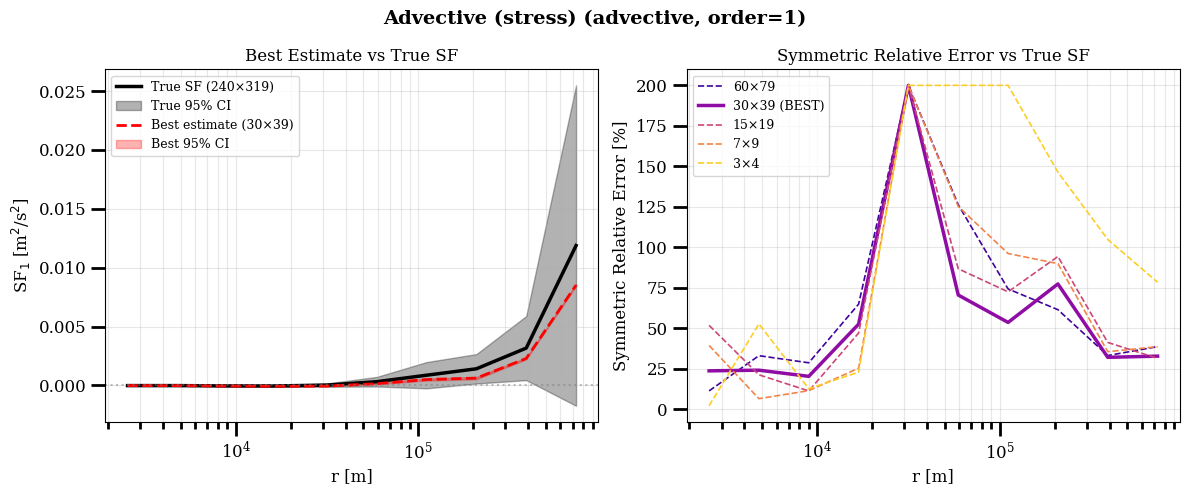

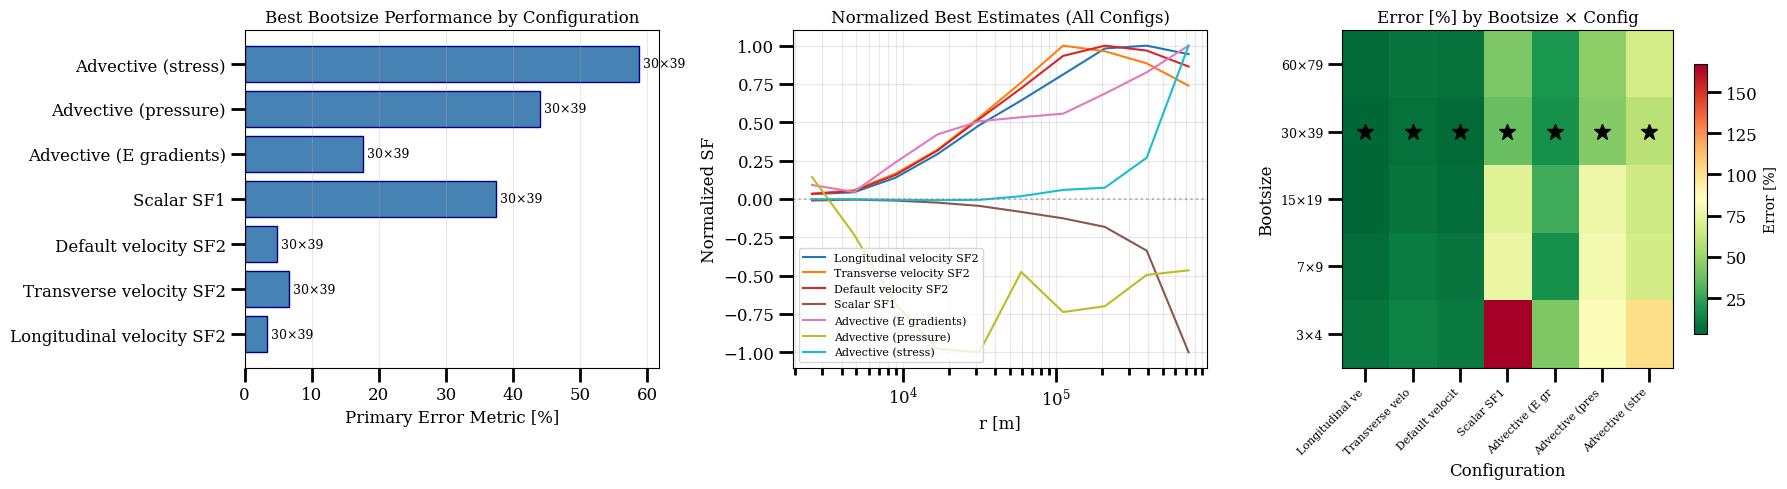

In [14]:
# =============================================================================
# CONFIGURATION
# =============================================================================

@dataclass
class SFConfig:
    """Structure function configuration."""
    name: str
    fun: str
    order: int
    variable_names: List[str]
    
    def __str__(self):
        return f"{self.name} ({self.fun}, order={self.order})"


# Define all configurations to test
SF_CONFIGS = [
    SFConfig(
        name="Longitudinal velocity SF2",
        fun='longitudinal',
        order=2,
        variable_names=['u', 'v']
    ),
    SFConfig(
        name="Transverse velocity SF2",
        fun='transverse',
        order=2,
        variable_names=['u', 'v']
    ),
    SFConfig(
        name="Default velocity SF2",
        fun='default_vel',
        order=2,
        variable_names=['u', 'v']
    ),
    SFConfig(
        name="Scalar SF1",
        fun='scalar',
        order=1,
        variable_names=['E']
    ),
    SFConfig(
        name="Advective (E gradients)",
        fun='advective',
        order=1,
        variable_names=['u', 'v', 'w', 'E_dx', 'E_dy', 'E_dz']
    ),
    SFConfig(
        name="Advective (pressure)",
        fun='advective',
        order=1,
        variable_names=['u', 'v', 'dpdx', 'dpdy']
    ),
    SFConfig(
        name="Advective (stress)",
        fun='advective',
        order=1,
        variable_names=['u', 'v', 'tau_x', 'tau_y']
    ),
]


# =============================================================================
# CORE FUNCTIONS
# =============================================================================

def generate_bootsizes(base_bootsize_x: int, base_bootsize_y: int, 
                       min_power: int = 2) -> Tuple[np.ndarray, np.ndarray]:
    """Generate bootsizes by dividing base sizes by powers of 2."""
    max_power = int(np.log2(min(base_bootsize_x, base_bootsize_y)))
    powers = np.arange(min_power, max_power)
    bootsizes_x = base_bootsize_x // (2 ** powers)
    bootsizes_y = base_bootsize_y // (2 ** powers)
    return bootsizes_x, bootsizes_y


def compute_robust_error_metrics(
    estimated: np.ndarray, 
    reference: np.ndarray,
    zero_threshold_percentile: float = 5.0
) -> Dict[str, float]:
    """
    Compute robust error metrics that handle negative and near-zero values.
    
    Uses multiple approaches:
    1. Symmetric MAPE: |a-b| / ((|a|+|b|)/2) - works for negative values
    2. Normalized RMSE: RMSE / range(reference) - scale-independent
    3. R² (coefficient of determination) - correlation-based
    4. Mean Absolute Error (MAE) - for reference
    
    Parameters
    ----------
    estimated : np.ndarray
        Estimated values
    reference : np.ndarray
        Reference (true) values
    zero_threshold_percentile : float
        Percentile of |reference| below which values are considered "near zero"
        
    Returns
    -------
    Dict with various error metrics
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        
        # Remove NaN pairs
        mask = ~(np.isnan(estimated) | np.isnan(reference))
        est = estimated[mask]
        ref = reference[mask]
        
        if len(est) == 0:
            return {
                'symmetric_mape': np.nan,
                'nrmse': np.nan,
                'r_squared': np.nan,
                'mae': np.nan,
                'rmse': np.nan,
                'max_abs_error': np.nan,
                'mean_rel_error': np.nan,  # For backward compatibility
                'max_rel_error': np.nan,
            }
        
        # Absolute differences
        abs_diff = np.abs(est - ref)
        
        # 1. Symmetric MAPE (handles negative values)
        # Formula: |a-b| / ((|a|+|b|)/2) * 100
        denominator = (np.abs(est) + np.abs(ref)) / 2
        # Avoid division by zero: use threshold based on data scale
        scale = np.nanpercentile(np.abs(ref), 100 - zero_threshold_percentile)
        threshold = scale * 1e-6 if scale > 0 else 1e-10
        valid_denom = denominator > threshold
        
        if np.any(valid_denom):
            symmetric_rel_error = np.where(
                valid_denom,
                abs_diff / denominator * 100,
                np.nan
            )
            symmetric_mape = np.nanmean(symmetric_rel_error)
            max_symmetric_rel = np.nanmax(symmetric_rel_error)
        else:
            symmetric_mape = np.nan
            max_symmetric_rel = np.nan
        
        # 2. RMSE and Normalized RMSE
        rmse = np.sqrt(np.nanmean(abs_diff ** 2))
        ref_range = np.nanmax(ref) - np.nanmin(ref)
        nrmse = (rmse / ref_range * 100) if ref_range > 0 else np.nan
        
        # 3. R² (coefficient of determination)
        ss_res = np.nansum((est - ref) ** 2)
        ss_tot = np.nansum((ref - np.nanmean(ref)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
        
        # 4. MAE
        mae = np.nanmean(abs_diff)
        
        # 5. Max absolute error
        max_abs_error = np.nanmax(abs_diff)
        
        # Traditional relative error (for cases where it makes sense)
        # Only compute where reference is not near zero
        ref_scale = np.nanpercentile(np.abs(ref), 90)
        near_zero_threshold = ref_scale * 0.01 if ref_scale > 0 else 1e-10
        valid_ref = np.abs(ref) > near_zero_threshold
        
        if np.any(valid_ref):
            trad_rel_error = np.where(
                valid_ref,
                abs_diff / np.abs(ref) * 100,
                np.nan
            )
            mean_rel_error = np.nanmean(trad_rel_error)
            max_rel_error = np.nanmax(trad_rel_error)
        else:
            mean_rel_error = symmetric_mape  # Fall back to symmetric
            max_rel_error = max_symmetric_rel
        
        return {
            'symmetric_mape': symmetric_mape,
            'nrmse': nrmse,
            'r_squared': r_squared,
            'mae': mae,
            'rmse': rmse,
            'max_abs_error': max_abs_error,
            'mean_rel_error': mean_rel_error,  # Backward compatible
            'max_rel_error': max_rel_error,
        }


def get_primary_error_metric(metrics: Dict, config: SFConfig) -> Tuple[str, float]:
    """
    Get the most appropriate error metric based on SF type.
    
    For advective/scalar (can be negative): use symmetric_mape or nrmse
    For velocity SFs (always positive): use traditional relative error
    """
    if config.fun in ['advective', 'scalar']:
        # Prefer symmetric MAPE, fall back to NRMSE
        if not np.isnan(metrics['symmetric_mape']):
            return 'symmetric_mape', metrics['symmetric_mape']
        else:
            return 'nrmse', metrics['nrmse']
    else:
        # Traditional relative error for positive-definite SFs
        return 'mean_rel_error', metrics['mean_rel_error']


def check_variables_exist(ds, variable_names: List[str]) -> bool:
    """Check if all required variables exist in the dataset."""
    missing = [var for var in variable_names if var not in ds.data_vars]
    if missing:
        print(f"  ⚠ Missing variables: {missing}")
        return False
    return True


def compute_sf_for_config(
    ds,
    config: SFConfig,
    bins: Dict,
    base_bootsize_x: int,
    base_bootsize_y: int,
    bootsizes_x: np.ndarray,
    bootsizes_y: np.ndarray,
    bootstrap_kwargs: Dict[str, Any]
) -> Optional[Dict[str, Any]]:
    """
    Compute structure functions for a single configuration across all bootsizes.
    
    Returns dict with true_sf, results, comparison_metrics, best_bootsize, best_estimate
    """
    print(f"\n{'='*70}")
    print(f"CONFIG: {config}")
    print(f"{'='*70}")
    
    # Check if variables exist
    if not check_variables_exist(ds, config.variable_names):
        print(f"  Skipping configuration due to missing variables.")
        return None
    
    # Base kwargs for this configuration
    base_kwargs = dict(
        ds=ds,
        variables_names=config.variable_names,
        bins=bins,
        fun=config.fun,
        order=config.order,
        **bootstrap_kwargs
    )
    
    # Compute "true" SF with largest bootsize
    print(f"\n  Computing TRUE SF with bootsize x={base_bootsize_x}, y={base_bootsize_y}...")
    try:
        true_sf = psf.get_isotropic_sf_2d(
            **base_kwargs,
            bootsize={'y': base_bootsize_y, 'x': base_bootsize_x}
        )
    except Exception as e:
        print(f"  ✗ Error computing true SF: {e}")
        return None
    
    # Store results for each bootsize
    results = {}
    
    # Test each bootsize
    for bsx, bsy in zip(bootsizes_x, bootsizes_y):
        print(f"  Computing SF with bootsize x={bsx}, y={bsy}...")
        try:
            sf_result = psf.get_isotropic_sf_2d(
                **base_kwargs,
                bootsize={'y': bsy, 'x': bsx}
            )
            results[(bsx, bsy)] = sf_result
        except Exception as e:
            print(f"    ✗ Error: {e}")
            continue
    
    if not results:
        print(f"  ✗ No valid results for this configuration.")
        return None
    
    # Extract true SF values
    true_sf_values = true_sf['sf'].values
    r_centers = true_sf['r'].values
    
    # Compute comparison metrics with robust error handling
    comparison_metrics = {}
    for (bsx, bsy), sf_result in results.items():
        sf_values = sf_result['sf'].values
        metrics = compute_robust_error_metrics(sf_values, true_sf_values)
        comparison_metrics[(bsx, bsy)] = metrics
    
    # Find best bootsize using appropriate metric for this SF type
    def get_best_metric_value(bs):
        _, value = get_primary_error_metric(comparison_metrics[bs], config)
        return value if not np.isnan(value) else np.inf
    
    best_bootsize = min(comparison_metrics.keys(), key=get_best_metric_value)
    best_sf = results[best_bootsize]
    
    # Get the metric name and value used
    metric_name, metric_value = get_primary_error_metric(
        comparison_metrics[best_bootsize], config
    )
    
    print(f"\n  {'─'*50}")
    print(f"  BEST BOOTSIZE: x={best_bootsize[0]}, y={best_bootsize[1]}")
    print(f"  Primary Metric ({metric_name}): {metric_value:.2f}%")
    print(f"  R²: {comparison_metrics[best_bootsize]['r_squared']:.4f}")
    print(f"  NRMSE: {comparison_metrics[best_bootsize]['nrmse']:.2f}%")
    print(f"  RMSE: {comparison_metrics[best_bootsize]['rmse']:.4e}")
    print(f"  {'─'*50}")
    
    # Store best estimate
    best_estimate = {
        'bootsize': best_bootsize,
        'sf': best_sf,
        'r': r_centers,
        'sf_values': best_sf['sf'].values,
        'ci_lower': best_sf['ci_lower'].values if 'ci_lower' in best_sf else None,
        'ci_upper': best_sf['ci_upper'].values if 'ci_upper' in best_sf else None,
        'metrics': comparison_metrics[best_bootsize]
    }
    
    return {
        'config': config,
        'true_sf': true_sf,
        'true_sf_values': true_sf_values,
        'r_centers': r_centers,
        'results': results,
        'comparison_metrics': comparison_metrics,
        'best_bootsize': best_bootsize,
        'best_estimate': best_estimate,
        'base_bootsize': (base_bootsize_x, base_bootsize_y)
    }


def plot_single_config(data: Dict, save_prefix: str = ""):
    """Plot results for a single configuration."""
    config = data['config']
    true_sf = data['true_sf']
    true_sf_values = data['true_sf_values']
    r_centers = data['r_centers']
    results = data['results']
    comparison_metrics = data['comparison_metrics']
    best_bootsize = data['best_bootsize']
    best_estimate = data['best_estimate']
    base_bootsize = data['base_bootsize']
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'{config}', fontsize=14, fontweight='bold')
    
    # Plot 1: Best estimate vs True SF
    ax1 = axes[0]
    
    # Check if data has negative values (advective, scalar can be negative)
    has_negative = np.any(true_sf_values < 0) or np.any(best_estimate['sf_values'] < 0)
    
    if has_negative:
        # Use linear scale for data with negative values
        ax1.plot(r_centers, true_sf_values, 'k-', lw=2.5, 
                 label=f'True SF ({base_bootsize[0]}×{base_bootsize[1]})')
        if 'ci_lower' in true_sf and 'ci_upper' in true_sf:
            ax1.fill_between(r_centers, 
                             true_sf['ci_lower'].values, 
                             true_sf['ci_upper'].values,
                             alpha=0.3, color='black', label='True 95% CI')
        
        ax1.plot(r_centers, best_estimate['sf_values'], 'r--', lw=2, 
                 label=f'Best estimate ({best_bootsize[0]}×{best_bootsize[1]})')
        if best_estimate['ci_lower'] is not None:
            ax1.fill_between(r_centers,
                             best_estimate['ci_lower'],
                             best_estimate['ci_upper'],
                             alpha=0.3, color='red', label='Best 95% CI')
        
        ax1.set_xscale('log')
        # Add zero line for reference
        ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    else:
        # Use log-log for positive-definite data
        ax1.loglog(r_centers, true_sf_values, 'k-', lw=2.5, 
                   label=f'True SF ({base_bootsize[0]}×{base_bootsize[1]})')
        if 'ci_lower' in true_sf and 'ci_upper' in true_sf:
            ax1.fill_between(r_centers, 
                             true_sf['ci_lower'].values, 
                             true_sf['ci_upper'].values,
                             alpha=0.3, color='black', label='True 95% CI')
        
        ax1.loglog(r_centers, best_estimate['sf_values'], 'r--', lw=2, 
                   label=f'Best estimate ({best_bootsize[0]}×{best_bootsize[1]})')
        if best_estimate['ci_lower'] is not None:
            ax1.fill_between(r_centers,
                             best_estimate['ci_lower'],
                             best_estimate['ci_upper'],
                             alpha=0.3, color='red', label='Best 95% CI')
    
    ax1.set_xlabel('r [m]', fontsize=12)
    ax1.set_ylabel(f'SF$_{config.order}$ [{get_units(config)}]', fontsize=12)
    ax1.set_title('Best Estimate vs True SF', fontsize=12)
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3, which='both')
    
    # Plot 2: Error for all bootsizes (use appropriate metric)
    ax2 = axes[1]
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(results)))
    
    # Determine if we should use symmetric error (for negative-capable SFs)
    use_symmetric = config.fun in ['advective', 'scalar']
    
    sorted_keys = sorted(results.keys(), key=lambda x: x[0], reverse=True)
    for i, (bsx, bsy) in enumerate(sorted_keys):
        sf_values = results[(bsx, bsy)]['sf'].values
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            
            if use_symmetric:
                # Symmetric relative error: |a-b| / ((|a|+|b|)/2) * 100
                denominator = (np.abs(sf_values) + np.abs(true_sf_values)) / 2
                # Threshold to avoid division by tiny numbers
                scale = np.nanpercentile(np.abs(true_sf_values), 95)
                threshold = scale * 1e-6 if scale > 0 else 1e-10
                error = np.where(
                    denominator > threshold,
                    np.abs(sf_values - true_sf_values) / denominator * 100,
                    np.nan
                )
            else:
                # Traditional relative error
                error = (np.abs(sf_values - true_sf_values) 
                        / np.abs(true_sf_values) * 100)
        
        lw = 2.5 if (bsx, bsy) == best_bootsize else 1.2
        ls = '-' if (bsx, bsy) == best_bootsize else '--'
        label = f'{bsx}×{bsy}' + (' (BEST)' if (bsx, bsy) == best_bootsize else '')
        ax2.semilogx(r_centers, error, ls, color=colors[i], lw=lw, label=label)
    
    error_type = 'Symmetric Relative' if use_symmetric else 'Relative'
    ax2.set_xlabel('r [m]', fontsize=12)
    ax2.set_ylabel(f'{error_type} Error [%]', fontsize=12)
    ax2.set_title(f'{error_type} Error vs True SF', fontsize=12)
    ax2.legend(loc='best', fontsize=9)
    ax2.grid(True, alpha=0.3, which='both')
    
    plt.tight_layout()
    
    # Save figure
    safe_name = config.name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    filename = f'{save_prefix}bootsize_sensitivity_{safe_name}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"  Saved: {filename}")
    
    return fig


def plot_summary(all_results: List[Dict], save_prefix: str = ""):
    """Plot summary comparison across all configurations."""
    n_configs = len(all_results)
    if n_configs == 0:
        print("No results to plot.")
        return None
    
    # Summary bar plot of best bootsizes and errors
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    config_names = [r['config'].name for r in all_results]
    best_errors = []
    for r in all_results:
        _, value = get_primary_error_metric(r['best_estimate']['metrics'], r['config'])
        best_errors.append(value)
    best_bootsizes = [f"{r['best_bootsize'][0]}×{r['best_bootsize'][1]}" for r in all_results]
    
    # Plot 1: Primary error metric (type-appropriate)
    ax1 = axes[0]
    bars = ax1.barh(config_names, best_errors, color='steelblue', edgecolor='navy')
    ax1.set_xlabel('Primary Error Metric [%]', fontsize=12)
    ax1.set_title('Best Bootsize Performance by Configuration', fontsize=12)
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Add bootsize labels on bars
    for bar, bs in zip(bars, best_bootsizes):
        width = bar.get_width()
        ax1.annotate(f'{bs}',
                    xy=(width, bar.get_y() + bar.get_height()/2),
                    xytext=(3, 0), textcoords="offset points",
                    ha='left', va='center', fontsize=9)
    
    # Plot 2: All configurations SF comparison (normalized)
    ax2 = axes[1]
    colors = plt.cm.tab10(np.linspace(0, 1, n_configs))
    
    for i, result in enumerate(all_results):
        r = result['r_centers']
        sf = result['best_estimate']['sf_values']
        # Normalize by max absolute value for comparison
        sf_norm = sf / np.nanmax(np.abs(sf))
        ax2.semilogx(r, sf_norm, '-', color=colors[i], lw=1.5, 
                   label=result['config'].name[:25])
    
    ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax2.set_xlabel('r [m]', fontsize=12)
    ax2.set_ylabel('Normalized SF', fontsize=12)
    ax2.set_title('Normalized Best Estimates (All Configs)', fontsize=12)
    ax2.legend(loc='best', fontsize=8)
    ax2.grid(True, alpha=0.3, which='both')
    
    # Plot 3: Bootsize ranking heatmap
    ax3 = axes[2]
    
    # Collect all bootsizes and create ranking matrix
    all_bootsizes = set()
    for result in all_results:
        all_bootsizes.update(result['comparison_metrics'].keys())
    all_bootsizes = sorted(all_bootsizes, key=lambda x: x[0], reverse=True)
    
    # Create error matrix (bootsizes x configs)
    error_matrix = np.zeros((len(all_bootsizes), n_configs))
    for j, result in enumerate(all_results):
        config = result['config']
        for i, bs in enumerate(all_bootsizes):
            if bs in result['comparison_metrics']:
                _, err = get_primary_error_metric(result['comparison_metrics'][bs], config)
                error_matrix[i, j] = err
            else:
                error_matrix[i, j] = np.nan
    
    # Plot heatmap
    im = ax3.imshow(error_matrix, aspect='auto', cmap='RdYlGn_r')
    ax3.set_xticks(range(n_configs))
    ax3.set_xticklabels([c[:15] for c in config_names], rotation=45, ha='right', fontsize=8)
    ax3.set_yticks(range(len(all_bootsizes)))
    ax3.set_yticklabels([f"{bs[0]}×{bs[1]}" for bs in all_bootsizes], fontsize=9)
    ax3.set_xlabel('Configuration', fontsize=12)
    ax3.set_ylabel('Bootsize', fontsize=12)
    ax3.set_title('Error [%] by Bootsize × Config', fontsize=12)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax3, shrink=0.8)
    cbar.set_label('Error [%]', fontsize=10)
    
    # Mark best bootsize for each config
    for j, result in enumerate(all_results):
        best_bs = result['best_bootsize']
        if best_bs in all_bootsizes:
            i = all_bootsizes.index(best_bs)
            ax3.plot(j, i, 'k*', markersize=12)
    
    plt.tight_layout()
    
    filename = f'{save_prefix}bootsize_sensitivity_summary.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"\nSaved summary: {filename}")
    
    return fig


def get_units(config: SFConfig) -> str:
    """Get appropriate units string for the SF type."""
    if config.fun in ['longitudinal', 'transverse', 'default_vel']:
        if config.order == 2:
            return 'm$^2$/s$^2$'
        elif config.order == 3:
            return 'm$^3$/s$^3$'
    elif config.fun == 'scalar':
        return 'units$^{' + str(config.order) + '}$'
    elif config.fun == 'advective':
        return 'm$^{' + str(config.order+1) + '}$/s$^{' + str(config.order+1) + '}$'
    return ''


def print_summary_table(all_results: List[Dict]):
    """Print summary table of all results."""
    print("\n" + "="*95)
    print("SUMMARY TABLE - ALL CONFIGURATIONS")
    print("="*95)
    print(f"{'Configuration':<30} {'Best Bootsize':<14} {'Primary Err %':<14} {'R²':<10} {'NRMSE %':<10}")
    print("-"*95)
    
    for result in all_results:
        config = result['config']
        config_name = config.name[:28]
        bs = result['best_bootsize']
        metrics = result['best_estimate']['metrics']
        
        # Get primary metric for this config type
        metric_name, metric_value = get_primary_error_metric(metrics, config)
        r2 = metrics['r_squared']
        nrmse = metrics['nrmse']
        
        print(f"{config_name:<30} {bs[0]}×{bs[1]:<9} "
              f"{metric_value:<14.2f} {r2:<10.4f} {nrmse:<10.2f}")
    
    print("="*95)


def print_detailed_table(data: Dict):
    """Print detailed table for a single configuration."""
    config = data['config']
    results = data['results']
    comparison_metrics = data['comparison_metrics']
    best_bootsize = data['best_bootsize']
    
    # Determine which metric to show based on SF type
    use_symmetric = config.fun in ['advective', 'scalar']
    metric_label = 'Sym.MAPE %' if use_symmetric else 'Rel.Err %'
    
    print(f"\n  DETAILED TABLE: {config.name}")
    print("  " + "-"*70)
    print(f"  {'Bootsize (x,y)':<16} {metric_label:<14} {'NRMSE %':<12} {'R²':<12}")
    print("  " + "-"*70)
    
    for bsx, bsy in sorted(results.keys(), key=lambda x: x[0], reverse=True):
        marker = " <-- BEST" if (bsx, bsy) == best_bootsize else ""
        m = comparison_metrics[(bsx, bsy)]
        
        if use_symmetric:
            primary_err = m['symmetric_mape']
        else:
            primary_err = m['mean_rel_error']
        
        print(f"  {bsx}×{bsy:<12} "
              f"{primary_err:<14.2f} "
              f"{m['nrmse']:<12.2f} "
              f"{m['r_squared']:<12.4f}{marker}")
    
    print("  " + "-"*70)


def find_overall_optimal_bootsize(
    all_results: List[Dict],
    method: str = 'mean_rank'
) -> Dict[str, Any]:
    """
    Find the single best bootsize that works well across ALL configurations.
    
    Parameters
    ----------
    all_results : List[Dict]
        Results from all configurations
    method : str
        Aggregation method:
        - 'mean_rank': Average rank across configs (lower is better)
        - 'mean_error': Average primary error across configs
        - 'max_error': Minimize the worst-case error across configs
        - 'mean_r2': Average R² across configs (higher is better)
        
    Returns
    -------
    Dict with optimal bootsize and analysis details
    """
    if not all_results:
        return None
    
    # Collect all bootsizes tested
    all_bootsizes = set()
    for result in all_results:
        all_bootsizes.update(result['comparison_metrics'].keys())
    all_bootsizes = sorted(all_bootsizes, key=lambda x: x[0], reverse=True)
    
    # Build a matrix of metrics: rows=bootsizes, cols=configs
    bootsize_scores = {bs: {'errors': [], 'r2s': [], 'ranks': []} for bs in all_bootsizes}
    
    for result in all_results:
        config = result['config']
        metrics_dict = result['comparison_metrics']
        
        # Get primary error for each bootsize in this config
        errors_for_config = {}
        for bs, metrics in metrics_dict.items():
            _, error_value = get_primary_error_metric(metrics, config)
            errors_for_config[bs] = error_value
            bootsize_scores[bs]['errors'].append(error_value)
            bootsize_scores[bs]['r2s'].append(metrics['r_squared'])
        
        # Compute ranks for this config (1 = best)
        sorted_bs = sorted(errors_for_config.keys(), 
                          key=lambda x: errors_for_config[x] if not np.isnan(errors_for_config[x]) else np.inf)
        for rank, bs in enumerate(sorted_bs, 1):
            bootsize_scores[bs]['ranks'].append(rank)
    
    # Compute aggregate scores
    aggregate_scores = {}
    for bs, scores in bootsize_scores.items():
        errors = [e for e in scores['errors'] if not np.isnan(e)]
        r2s = [r for r in scores['r2s'] if not np.isnan(r)]
        ranks = scores['ranks']
        
        aggregate_scores[bs] = {
            'mean_error': np.mean(errors) if errors else np.inf,
            'max_error': np.max(errors) if errors else np.inf,
            'mean_r2': np.mean(r2s) if r2s else -np.inf,
            'mean_rank': np.mean(ranks) if ranks else np.inf,
            'n_configs': len(errors)
        }
    
    # Select optimal based on method
    if method == 'mean_rank':
        optimal_bs = min(aggregate_scores.keys(), 
                        key=lambda x: aggregate_scores[x]['mean_rank'])
    elif method == 'mean_error':
        optimal_bs = min(aggregate_scores.keys(), 
                        key=lambda x: aggregate_scores[x]['mean_error'])
    elif method == 'max_error':
        optimal_bs = min(aggregate_scores.keys(), 
                        key=lambda x: aggregate_scores[x]['max_error'])
    elif method == 'mean_r2':
        optimal_bs = max(aggregate_scores.keys(), 
                        key=lambda x: aggregate_scores[x]['mean_r2'])
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Check how many configs agree with this choice
    agreement_count = sum(
        1 for result in all_results 
        if result['best_bootsize'] == optimal_bs
    )
    
    return {
        'optimal_bootsize': optimal_bs,
        'method': method,
        'aggregate_scores': aggregate_scores,
        'optimal_scores': aggregate_scores[optimal_bs],
        'agreement': f"{agreement_count}/{len(all_results)} configs",
        'all_bootsizes_ranked': sorted(
            aggregate_scores.keys(),
            key=lambda x: aggregate_scores[x][method if method != 'mean_r2' else 'mean_rank']
        )
    }


def print_overall_optimal(optimal_result: Dict, all_results: List[Dict]):
    """Print the overall optimal bootsize analysis."""
    if optimal_result is None:
        print("\nNo results to analyze.")
        return
    
    opt_bs = optimal_result['optimal_bootsize']
    scores = optimal_result['aggregate_scores']
    
    print("\n" + "="*95)
    print("★ OVERALL OPTIMAL BOOTSIZE ANALYSIS ★")
    print("="*95)
    
    print(f"\n  Method: {optimal_result['method']}")
    print(f"  ★ OPTIMAL BOOTSIZE: {opt_bs[0]} × {opt_bs[1]}")
    print(f"  Agreement: {optimal_result['agreement']} configurations chose this as their best")
    
    opt_scores = optimal_result['optimal_scores']
    print(f"\n  Aggregate metrics for optimal bootsize:")
    print(f"    Mean Error:  {opt_scores['mean_error']:.2f}%")
    print(f"    Max Error:   {opt_scores['max_error']:.2f}%")
    print(f"    Mean R²:     {opt_scores['mean_r2']:.4f}")
    print(f"    Mean Rank:   {opt_scores['mean_rank']:.1f}")
    
    # Ranking table
    print(f"\n  {'Bootsize':<14} {'Mean Err %':<12} {'Max Err %':<12} {'Mean R²':<10} {'Mean Rank':<10}")
    print("  " + "-"*70)
    
    for bs in optimal_result['all_bootsizes_ranked']:
        s = scores[bs]
        marker = " ★ OPTIMAL" if bs == opt_bs else ""
        print(f"  {bs[0]}×{bs[1]:<9} {s['mean_error']:<12.2f} {s['max_error']:<12.2f} "
              f"{s['mean_r2']:<10.4f} {s['mean_rank']:<10.1f}{marker}")
    
    print("  " + "-"*70)
    
    # Show per-config performance with optimal bootsize
    print(f"\n  Performance of optimal bootsize ({opt_bs[0]}×{opt_bs[1]}) per configuration:")
    print("  " + "-"*70)
    print(f"  {'Configuration':<30} {'Error %':<12} {'R²':<10} {'Is Best?':<10}")
    print("  " + "-"*70)
    
    for result in all_results:
        config = result['config']
        if opt_bs in result['comparison_metrics']:
            metrics = result['comparison_metrics'][opt_bs]
            _, error = get_primary_error_metric(metrics, config)
            r2 = metrics['r_squared']
            is_best = "✓ YES" if result['best_bootsize'] == opt_bs else "no"
            print(f"  {config.name[:28]:<30} {error:<12.2f} {r2:<10.4f} {is_best}")
        else:
            print(f"  {config.name[:28]:<30} {'N/A':<12} {'N/A':<10} {'N/A'}")
    
    print("="*95)


# =============================================================================
# MAIN ANALYSIS FUNCTION
# =============================================================================

def run_bootsize_sensitivity_analysis(
    ds,
    configs: List[SFConfig] = None,
    base_bootsize_x: int = 240,
    base_bootsize_y: int = 319,
    nbins: int = 11,
    r_min: float = 1.0e3,
    r_max: float = 1.0e6,
    initial_nbootstrap: int = 6000,
    max_nbootstrap: int = 6000,
    step_nbootstrap: int = 0,
    convergence_eps: float = 0.001,
    confidence_interval: float = 0.95,
    n_jobs: int = -1,
    backend: str = 'loky',
    seed: int = 42,
    save_plots: bool = True,
    save_prefix: str = "",
    show_plots: bool = True
) -> Dict[str, Any]:
    """
    Run bootsize sensitivity analysis for multiple SF configurations.
    
    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset with required variables
    configs : List[SFConfig], optional
        List of configurations to test. If None, uses SF_CONFIGS.
    base_bootsize_x, base_bootsize_y : int
        Base bootsize for "true" SF computation
    nbins : int
        Number of bins for separation distances
    r_min, r_max : float
        Min and max separation distances [m]
    initial_nbootstrap, max_nbootstrap, step_nbootstrap : int
        Bootstrap parameters
    convergence_eps : float
        Convergence tolerance
    confidence_interval : float
        Confidence interval level
    n_jobs : int
        Number of parallel jobs (-1 for all cores)
    backend : str
        Parallel backend
    seed : int
        Random seed for reproducibility
    save_plots : bool
        Whether to save plots
    save_prefix : str
        Prefix for saved files
    show_plots : bool
        Whether to display plots
        
    Returns
    -------
    Dict with all results, summary, and figures
    """
    if configs is None:
        configs = SF_CONFIGS
    
    # Define bins
    bin_r = np.logspace(np.log10(r_min), np.log10(r_max), int(nbins + 1))
    bins = {'r': bin_r}
    
    # Generate bootsizes
    bootsizes_x, bootsizes_y = generate_bootsizes(base_bootsize_x, base_bootsize_y)
    
    print("="*70)
    print("BOOTSIZE SENSITIVITY ANALYSIS")
    print("="*70)
    print(f"\nBase bootsize: {base_bootsize_x} × {base_bootsize_y}")
    print(f"Testing bootsizes (x, y):")
    for bsx, bsy in zip(bootsizes_x, bootsizes_y):
        print(f"  {bsx} × {bsy}")
    print(f"\nNumber of configurations to test: {len(configs)}")
    for i, cfg in enumerate(configs):
        print(f"  {i+1}. {cfg}")
    
    # Bootstrap kwargs
    bootstrap_kwargs = dict(
        initial_nbootstrap=initial_nbootstrap,
        max_nbootstrap=max_nbootstrap,
        step_nbootstrap=step_nbootstrap,
        convergence_eps=convergence_eps,
        confidence_interval=confidence_interval,
        n_jobs=n_jobs,
        backend=backend,
        seed=seed
    )
    
    # Run analysis for each configuration
    all_results = []
    figures = []
    
    for config in configs:
        result = compute_sf_for_config(
            ds=ds,
            config=config,
            bins=bins,
            base_bootsize_x=base_bootsize_x,
            base_bootsize_y=base_bootsize_y,
            bootsizes_x=bootsizes_x,
            bootsizes_y=bootsizes_y,
            bootstrap_kwargs=bootstrap_kwargs
        )
        
        if result is not None:
            all_results.append(result)
            
            # Print detailed table
            print_detailed_table(result)
            
            # Plot individual results
            if save_plots or show_plots:
                fig = plot_single_config(result, save_prefix=save_prefix)
                figures.append(fig)
    
    # Print summary
    if all_results:
        print_summary_table(all_results)
        
        # Find overall optimal bootsize
        optimal_result = find_overall_optimal_bootsize(all_results, method='mean_rank')
        print_overall_optimal(optimal_result, all_results)
        
        # Plot summary
        if save_plots or show_plots:
            summary_fig = plot_summary(all_results, save_prefix=save_prefix)
            figures.append(summary_fig)
    else:
        optimal_result = None
    
    if show_plots:
        plt.show()
    
    return {
        'all_results': all_results,
        'figures': figures,
        'configs': configs,
        'bootsizes': list(zip(bootsizes_x, bootsizes_y)),
        'base_bootsize': (base_bootsize_x, base_bootsize_y),
        'overall_optimal': optimal_result
    }


# =============================================================================
# EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":
    # Example usage - uncomment and modify as needed
    
    # # Load your dataset
    # import xarray as xr
    ds = xr.open_dataset('/home/aayouche/Downloads/Gi_example_output.nc')

    
    # # Run full analysis with all configs
    results = run_bootsize_sensitivity_analysis(
         ds=ds,
         base_bootsize_x=240,
         base_bootsize_y=319,
         save_prefix='analysis_',
         show_plots=False
     )
    
    # # Access the OVERALL OPTIMAL bootsize (works across all configs)
    # optimal = results['overall_optimal']
    # print(f"Overall optimal bootsize: {optimal['optimal_bootsize']}")
    # print(f"Mean error: {optimal['optimal_scores']['mean_error']:.2f}%")
    # print(f"Mean R²: {optimal['optimal_scores']['mean_r2']:.4f}")
    
    # # Or run with specific configs only
    # selected_configs = [
    #     SFConfig(name="Longitudinal SF2", fun='longitudinal', order=2, variable_names=['u', 'v']),
    #     SFConfig(name="Scalar SF1", fun='scalar', order=1, variable_names=['E']),
    # ]
    # results = run_bootsize_sensitivity_analysis(
    #     ds=ds,
    #     configs=selected_configs,
    #     save_prefix='selected_'
    # )
    
    print("Script loaded. Import and call run_bootsize_sensitivity_analysis() with your dataset.")
    print("\nExample:")
    print("  from bootsize_sensitivity_analysis import run_bootsize_sensitivity_analysis, SFConfig")
    print("  results = run_bootsize_sensitivity_analysis(ds=your_dataset)")
    print("\n  # Get overall optimal bootsize:")
    print("  optimal_bs = results['overall_optimal']['optimal_bootsize']")
    print("  print(f'Use bootsize: {optimal_bs[0]} x {optimal_bs[1]}')")